# LeetCode #76: Minimum Window Substring

https://leetcode.com/problems/minimum-window-substring/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Brute Force (all substrings) | O(n²·m) | O(m) | Check every substring |
| **Sliding Window + HashMap ★** | **O(n+m)** | **O(m)** | Expand right, shrink left; track `formed` counter |

---

## Understanding the Methods

### Brute Force
Generate all substrings of s and check each for containing all chars of t. O(n²) substrings × O(m) check = O(n²·m).

### Optimal: Sliding Window + HashMap ★
Key insight: use a `formed` counter tracking how many distinct t-characters have been fully satisfied.

1. Build `need` map (t's char frequencies), set `required = need.Count`.
2. **Expand** right pointer: add s[r] to window. If window[s[r]] == need[s[r]], increment `formed`.
3. **Shrink** left while formed==required: record min window, remove s[l], if window[s[l]] < need[s[l]] decrement formed.
4. Return recorded minimum.

**Constraints:**
* m == s.length, n == t.length
* 1 <= m, n <= 10^5
* s and t consist of uppercase and lowercase English letters

## Solutions

### C#

In [ ]:
public class Solution {
    public string MinWindow(string s, string t) {
        var need = new Dictionary<char, int>();
        foreach (var c in t) need[c] = need.GetValueOrDefault(c) + 1;
        int required = need.Count, formed = 0;
        var window = new Dictionary<char, int>();
        int l = 0, minLen = int.MaxValue, minL = 0;

        for (int r = 0; r < s.Length; r++) {
            char c = s[r];
            window[c] = window.GetValueOrDefault(c) + 1;
            if (need.ContainsKey(c) && window[c] == need[c])
                formed++;

            while (formed == required) {
                if (r - l + 1 < minLen) {
                    minLen = r - l + 1;
                    minL = l;
                }
                char lc = s[l++];
                window[lc]--;
                if (need.ContainsKey(lc) && window[lc] < need[lc])
                    formed--;
            }
        }

        return minLen == int.MaxValue ? "" : s.Substring(minL, minLen);
    }
}

### Python

In [ ]:
from collections import Counter

class Solution:
    def minWindow(self, s: str, t: str) -> str:
        if not t or not s:
            return ""
        need = Counter(t)
        required = len(need)
        window = {}
        formed = 0
        l = 0
        min_len = float('inf')
        min_l = 0

        for r, c in enumerate(s):
            window[c] = window.get(c, 0) + 1
            if c in need and window[c] == need[c]:
                formed += 1

            while formed == required:
                if r - l + 1 < min_len:
                    min_len = r - l + 1
                    min_l = l
                lc = s[l]
                window[lc] -= 1
                if lc in need and window[lc] < need[lc]:
                    formed -= 1
                l += 1

        return "" if min_len == float('inf') else s[min_l:min_l + min_len]

### Go

In [ ]:
func minWindow(s string, t string) string {
    need := make(map[byte]int)
    for i := 0; i < len(t); i++ {
        need[t[i]]++
    }
    required := len(need)
    window := make(map[byte]int)
    formed := 0
    l := 0
    minLen := math.MaxInt32
    minL := 0

    for r := 0; r < len(s); r++ {
        c := s[r]
        window[c]++
        if cnt, ok := need[c]; ok && window[c] == cnt {
            formed++
        }
        for formed == required {
            if r-l+1 < minLen {
                minLen = r - l + 1
                minL = l
            }
            lc := s[l]
            window[lc]--
            if cnt, ok := need[lc]; ok && window[lc] < cnt {
                formed--
            }
            l++
        }
    }

    if minLen == math.MaxInt32 {
        return ""
    }
    return s[minL : minL+minLen]
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn min_window(s: String, t: String) -> String {
        let mut need: HashMap<u8, i32> = HashMap::new();
        for c in t.bytes() { *need.entry(c).or_insert(0) += 1; }
        let required = need.len();
        let mut window: HashMap<u8, i32> = HashMap::new();
        let (mut formed, mut l) = (0usize, 0usize);
        let (mut min_len, mut min_l) = (usize::MAX, 0usize);
        let sb = s.as_bytes();

        for (r, &c) in sb.iter().enumerate() {
            *window.entry(c).or_insert(0) += 1;
            if let Some(&n) = need.get(&c) {
                if window[&c] == n { formed += 1; }
            }
            while formed == required {
                if r - l + 1 < min_len { min_len = r - l + 1; min_l = l; }
                let lc = sb[l];
                *window.get_mut(&lc).unwrap() -= 1;
                if let Some(&n) = need.get(&lc) {
                    if window[&lc] < n { formed -= 1; }
                }
                l += 1;
            }
        }

        if min_len == usize::MAX { String::new() }
        else { s[min_l..min_l+min_len].to_string() }
    }
}

## Example Scenarios

### 1. Common Case — Classic Sliding Window
**Input:** `s = "ADOBECODEBANC"`, `t = "ABC"`

need = {A:1, B:1, C:1}, required = 3. Window expands to `[0,5]` = "ADOBEC" (formed = 3). Shrink left: removing A breaks it. Continue expanding. Eventually `[9,12]` = "BANC" (length 4) beats previous best of 6.

**Why it’s useful:** Demonstrates the full expand-shrink-expand cycle. The best window is found at the tail, not the first valid window.

### 2. Slightly Complex — Duplicate Characters in t
**Input:** `s = "AAABBBCCC"`, `t = "AABBCC"`

need = {A:2, B:2, C:2}, required = 3. The `formed` counter increments only when $window[c] = need[c]$ (exact match), not when $window[c] > need[c]$. Window `[1,7]` = "AABBBCC" is the minimum at length 7.

**Why it’s tricky:** Duplicate chars in $t$ test that `formed` uses equality, not $\ge$. Overcounting (window[A]=3) doesn’t double-increment formed.

### 3. Edge Case: Time Factor — Match at Very End of s
**Input:** `s = "X" * 99999 + "A"`, `t = "A"` ($|s| = 10^5$)

Right pointer scans $10^5$ chars before finding A at index 99999. Then left pointer shrinks $10^5 - 1$ positions. Total: $O(2n) = O(n)$. Each pointer moves at most $n$ times.

**Why it’s tricky:** Maximum input forces a full scan before any valid window. Confirms amortized $O(n + m)$ — the left pointer never revisits positions.

### 4. Edge Case: Space Factor — No Valid Window
**Input:** `s = "ABCDEFGHIJKLMNOPQRSTUVWXY"`, `t = "Z"`

Z never appears in s. `formed` stays 0 forever. The window HashMap accumulates all 25 distinct chars of s, but none match the need map. Return `""`.

**Why it’s tricky:** Window map grows to hold every char in s (max 52 letters = $O(1)$). The shrink loop never executes. Tests the `minLen == MAX` fallback.

### 5. Almost-Impossible but Plausible — t Longer Than s
**Input:** `s = "aaaa"`, `t = "aaaaa"` ($|t| > |s|$)

need = {a:5}, required = 1. Even the entire string only gives window[a] = 4 < need[a] = 5. `formed` never reaches `required`. Return `""`.

**Why it’s tricky:** The problem says $1 \le |t| \le 10^5$ with no guarantee $|t| \le |s|$. Naive implementations that assume a valid window exists will return garbage instead of `""`.


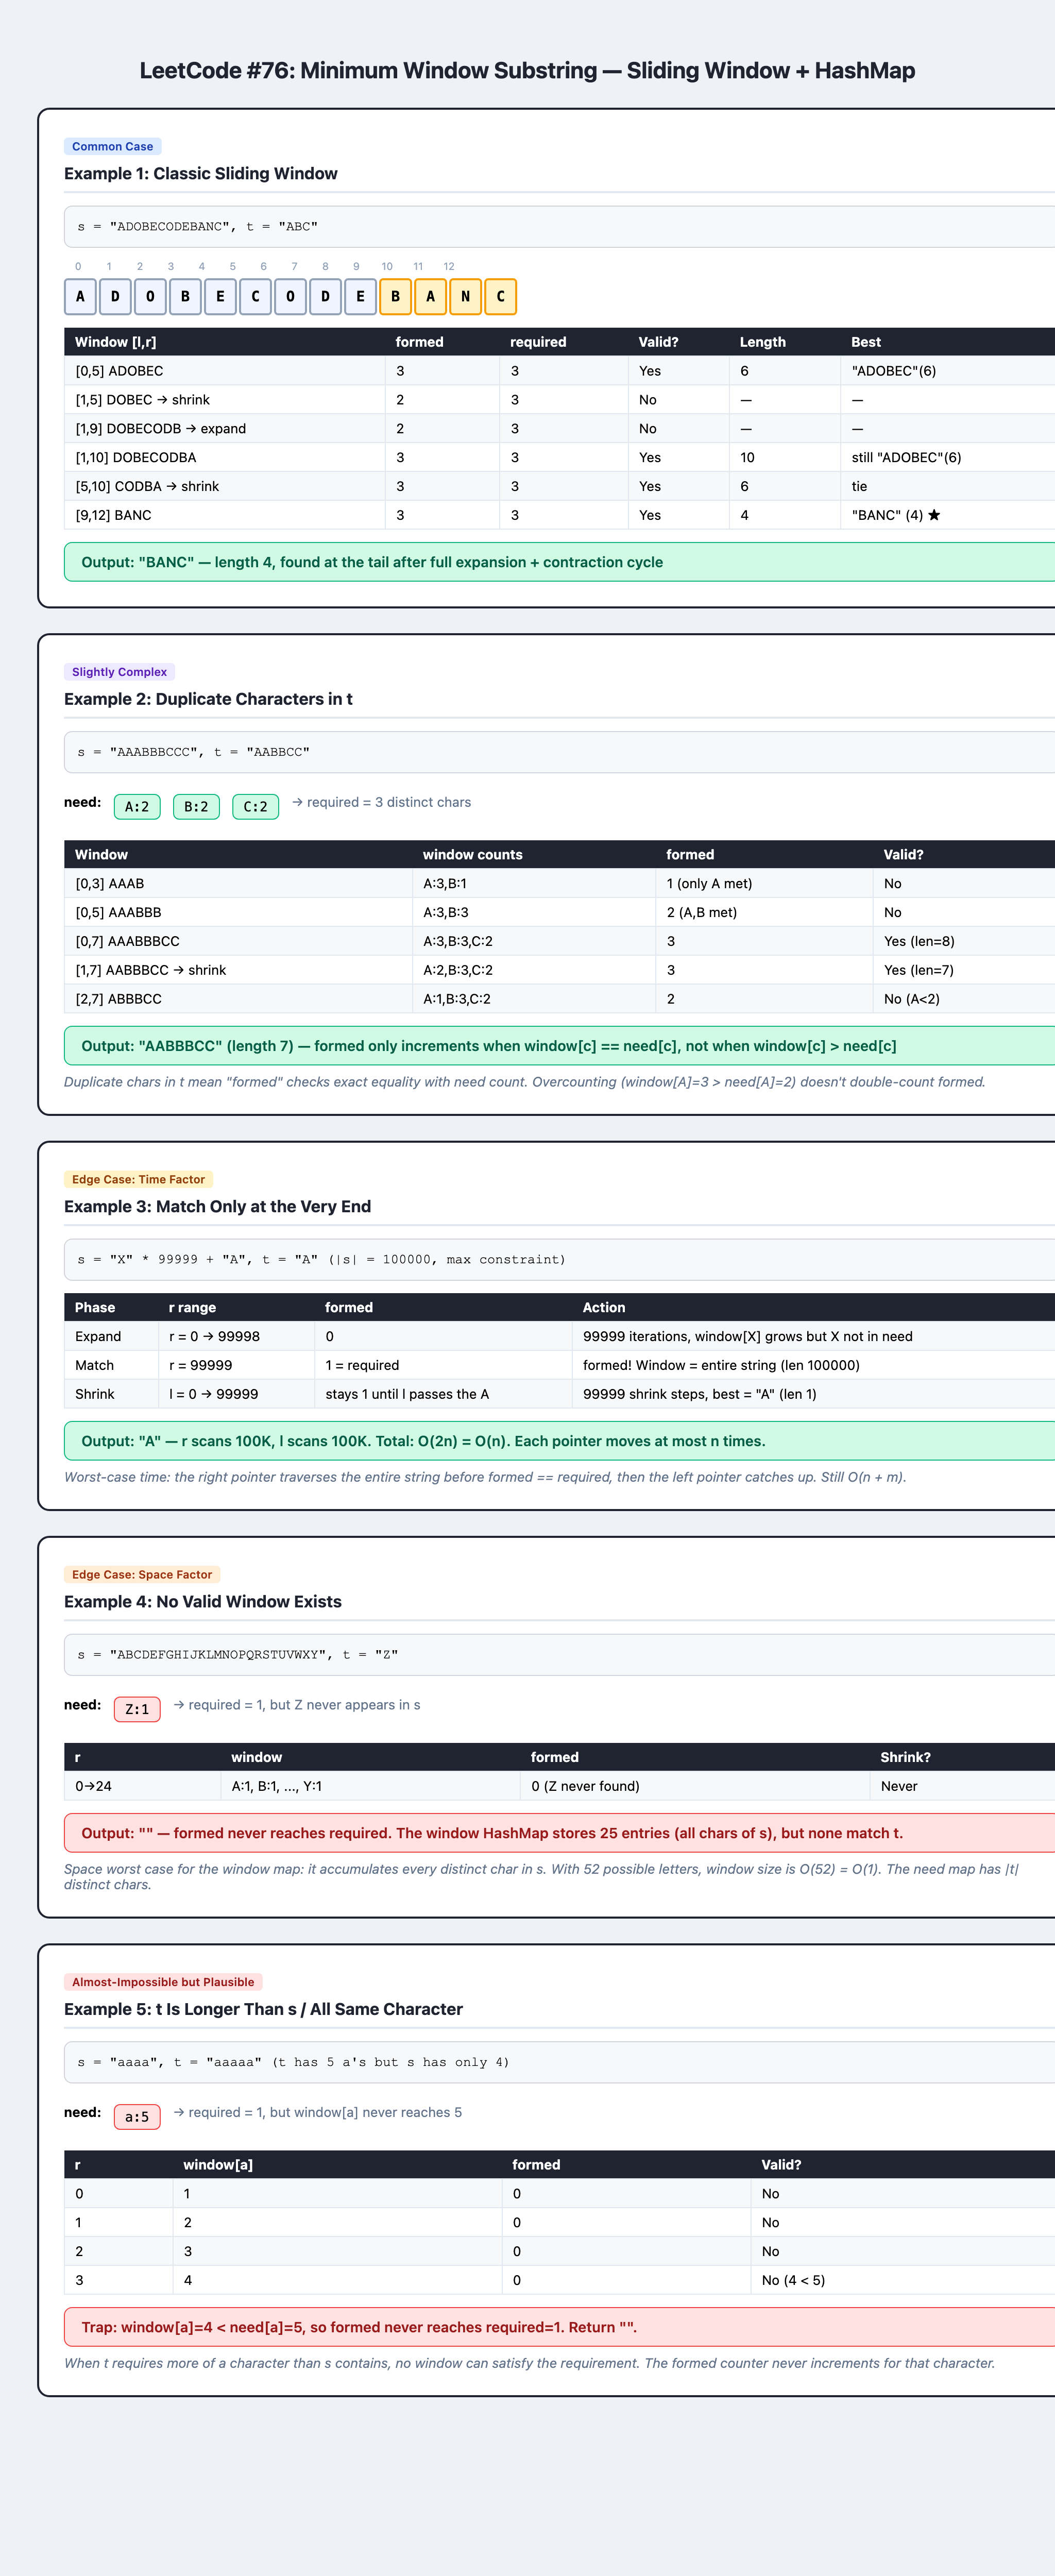